# 03 — Task Generalization

Does the expectile-vs-quantile noise-robustness advantage from notebook 02
show up in actual decision-making, across qualitatively different task
structures? Three active multi-armed-bandit tasks, each stressing a
different aspect of the same magnitude-scaled-vs-fixed-step update
distinction:

1. **Non-stationary bandit** — abrupt shifts in which arm is best.
2. **Gradual drift bandit** — continuously drifting arm means, no discrete
   change points.
3. **Risk-sensitive survival task** — the best arm is also the noisiest,
   under a resource budget that punishes slow identification.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, ttest_ind, sem

import rw_utils as rwu

ARTIFACT_DIR = "artifacts"
const = np.load(os.path.join(ARTIFACT_DIR, "empirical_constants.npz"))
EMP_AI = dict(zip(const["stat_names"], const["ai_mean"]))
EMP_COS = dict(zip(const["stat_names"], const["cos_align_mean"]))
L_POOLED = const["L_pooled"]
N_UNITS_RW = int(const["n_units_rw"])
OBS_NOISE_SD = float(const["obs_noise_sd"])
N_TRIALS_PER_ODOR = int(const["median_trials_per_condition"])
N_PROBE = max(5, N_TRIALS_PER_ODOR // 2)

print(f"Loaded empirical constants: AI={dict((k, round(float(v), 3)) for k, v in EMP_AI.items())}")
print(f"RW population size (matches noise calibration): {N_UNITS_RW}")
print(f"Trial regime from real data: {N_TRIALS_PER_ODOR} trials/odor, probing last {N_PROBE}")

Loaded empirical constants: AI={np.str_('mean'): 0.623, np.str_('variance'): 0.098, np.str_('kurtosis'): 0.006}
RW population size (matches noise calibration): 50
Trial regime from real data: 35 trials/odor, probing last 17


## Task 1: Non-stationary bandit

In [2]:
N_ARMS_NS, N_TRIALS_NS, CHANGE_INTERVAL, N_SEEDS_NS = 4, 2000, 200, 30
ARM_VARS_NS = [0.0, 2.0, 4.0, 6.0]

def means_at_phase(phase, n_arms=N_ARMS_NS, best_bonus=2.0):
    base = [4.0] * n_arms
    base[phase % n_arms] += best_bonus
    return base

def make_ns_reward_fn(n_arms=N_ARMS_NS):
    def reward_fn(arm, t, rng):
        phase = t // CHANGE_INTERVAL
        mu = means_at_phase(phase, n_arms)[arm]
        sd = np.sqrt(ARM_VARS_NS[arm])
        return rng.normal(mu, sd) if sd > 1e-9 else mu
    return reward_fn

NOISE_LEVELS = [0.0, 1.0, 2.0]
ns_rows, ns_recovery_rows = [], []
reward_fn_ns = make_ns_reward_fn()
for ln_sd in NOISE_LEVELS:
    for rule in ["expectile", "quantile"]:
        for seed in range(N_SEEDS_NS):
            out = rwu.run_bandit(reward_fn_ns, N_ARMS_NS, N_TRIALS_NS, rule,
                                  alpha=0.15, learn_noise_sd=ln_sd, init_value=4.0, seed=seed)
            optimal = np.array([np.argmax(means_at_phase(t // CHANGE_INTERVAL)) for t in range(N_TRIALS_NS)])
            is_opt = (out["choices"] == optimal).astype(float)
            regret = np.array([means_at_phase(t // CHANGE_INTERVAL)[optimal[t]] - out["rewards"][t]
                                for t in range(N_TRIALS_NS)])
            ns_rows.append(dict(rule=rule, noise=ln_sd, seed=seed, frac_opt=is_opt.mean(),
                                 total_regret=regret.sum(), frac_opt_last_half=is_opt[N_TRIALS_NS // 2:].mean()))
            for cp in range(CHANGE_INTERVAL, N_TRIALS_NS, CHANGE_INTERVAL):
                window = is_opt[cp:min(cp + 100, N_TRIALS_NS)]
                smooth = np.convolve(window, np.ones(20) / 20, mode="valid")
                rec = int(np.argmax(smooth >= 0.7)) if (smooth >= 0.7).any() else 100
                ns_recovery_rows.append(dict(rule=rule, noise=ln_sd, seed=seed, recovery_trials=rec))

df_ns = pd.DataFrame(ns_rows)
df_ns_recovery = pd.DataFrame(ns_recovery_rows)

print("Fraction-optimal and regret, expectile vs. quantile:")
for ln_sd in NOISE_LEVELS:
    for metric in ["frac_opt", "total_regret", "frac_opt_last_half"]:
        e = df_ns[(df_ns.rule == "expectile") & (df_ns.noise == ln_sd)][metric]
        q = df_ns[(df_ns.rule == "quantile") & (df_ns.noise == ln_sd)][metric]
        _, p = ttest_ind(e, q)
        print(f"  noise={ln_sd:.1f}  {metric:20s}  exp={e.mean():8.2f}  quant={q.mean():8.2f}  "
              f"diff={e.mean()-q.mean():+8.2f}  p={p:.4f}")
    e_r = df_ns_recovery[(df_ns_recovery.rule == "expectile") & (df_ns_recovery.noise == ln_sd)]["recovery_trials"]
    q_r = df_ns_recovery[(df_ns_recovery.rule == "quantile") & (df_ns_recovery.noise == ln_sd)]["recovery_trials"]
    _, p_r = ttest_ind(e_r, q_r)
    print(f"  noise={ln_sd:.1f}  recovery_trials       exp={e_r.mean():8.2f}  quant={q_r.mean():8.2f}  "
          f"diff={e_r.mean()-q_r.mean():+8.2f}  p={p_r:.4f}")

Fraction-optimal and regret, expectile vs. quantile:
  noise=0.0  frac_opt              exp=    0.62  quant=    0.49  diff=   +0.14  p=0.0000
  noise=0.0  total_regret          exp= 1509.56  quant= 2052.37  diff= -542.80  p=0.0000
  noise=0.0  frac_opt_last_half    exp=    0.58  quant=    0.46  diff=   +0.12  p=0.0000
  noise=0.0  recovery_trials       exp=   57.39  quant=   80.42  diff=  -23.03  p=0.0000
  noise=1.0  frac_opt              exp=    0.62  quant=    0.46  diff=   +0.16  p=0.0000
  noise=1.0  total_regret          exp= 1516.64  quant= 2170.05  diff= -653.40  p=0.0000
  noise=1.0  frac_opt_last_half    exp=    0.58  quant=    0.40  diff=   +0.19  p=0.0000
  noise=1.0  recovery_trials       exp=   59.54  quant=   81.97  diff=  -22.43  p=0.0000
  noise=2.0  frac_opt              exp=    0.59  quant=    0.39  diff=   +0.20  p=0.0000
  noise=2.0  total_regret          exp= 1640.91  quant= 2433.10  diff= -792.19  p=0.0000
  noise=2.0  frac_opt_last_half    exp=    0.55  quant=  

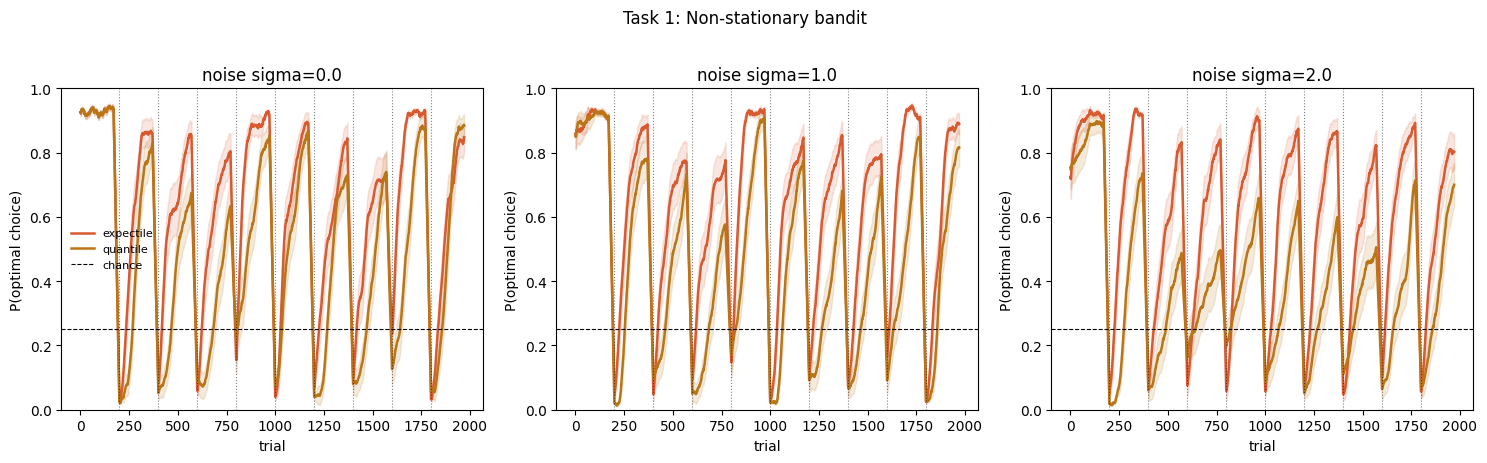

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
WIN = 30
for ni, ln_sd in enumerate(NOISE_LEVELS):
    ax = axes[ni]
    for rule in ["expectile", "quantile"]:
        all_opt = []
        for seed in range(N_SEEDS_NS):
            out = rwu.run_bandit(reward_fn_ns, N_ARMS_NS, N_TRIALS_NS, rule,
                                  alpha=0.15, learn_noise_sd=ln_sd, init_value=4.0, seed=seed)
            optimal = np.array([np.argmax(means_at_phase(t // CHANGE_INTERVAL)) for t in range(N_TRIALS_NS)])
            smooth = np.convolve((out["choices"] == optimal).astype(float), np.ones(WIN) / WIN, mode="valid")
            all_opt.append(smooth)
        all_opt = np.array(all_opt)
        xs = np.arange(all_opt.shape[1])
        ax.plot(xs, all_opt.mean(axis=0), color=rwu.RULE_COLORS[rule], lw=1.8, label=rule)
        ax.fill_between(xs, all_opt.mean(axis=0) - sem(all_opt, axis=0),
                         all_opt.mean(axis=0) + sem(all_opt, axis=0), alpha=0.15, color=rwu.RULE_COLORS[rule])
    for cp in range(CHANGE_INTERVAL, N_TRIALS_NS, CHANGE_INTERVAL):
        ax.axvline(cp, color="k", ls=":", lw=0.8, alpha=0.5)
    ax.axhline(1 / N_ARMS_NS, color="k", ls="--", lw=0.8, label="chance")
    ax.set_xlabel("trial"); ax.set_ylabel("P(optimal choice)"); ax.set_ylim(0, 1)
    ax.set_title(f"noise sigma={ln_sd}")
    if ni == 0:
        ax.legend(fontsize=8, frameon=False)
plt.suptitle("Task 1: Non-stationary bandit", y=1.02)
plt.tight_layout()
fig_dir = os.path.join(ARTIFACT_DIR, "..", "figures")
os.makedirs(fig_dir, exist_ok=True)
plt.savefig(os.path.join(fig_dir, "03_task1_nonstationary.pdf"), bbox_inches="tight")
plt.show()

df_ns.to_csv(os.path.join(ARTIFACT_DIR, "task1_nonstationary.csv"), index=False)

## Task 2: Gradual drift bandit

In [4]:
N_ARMS_DRIFT, N_TRIALS_DRIFT, N_SEEDS_DRIFT = 4, 2000, 30
BASE_MEAN, DRIFT_AMP, DRIFT_PERIOD = 4.0, 2.0, 400
ARM_PHASES = [i * np.pi / 2 for i in range(N_ARMS_DRIFT)]
ARM_VAR_DRIFT = [0.5, 1.0, 2.0, 3.0]

def true_mean_at_t(arm, t):
    return BASE_MEAN + DRIFT_AMP * np.sin(2 * np.pi * t / DRIFT_PERIOD + ARM_PHASES[arm])

def make_drift_reward_fn():
    def reward_fn(arm, t, rng):
        mu = true_mean_at_t(arm, t)
        sd = np.sqrt(ARM_VAR_DRIFT[arm])
        return rng.normal(mu, sd) if sd > 1e-9 else mu
    return reward_fn

reward_fn_drift = make_drift_reward_fn()
drift_rows = []
for ln_sd in NOISE_LEVELS:
    for rule in ["expectile", "quantile"]:
        for seed in range(N_SEEDS_DRIFT):
            out = rwu.run_bandit(reward_fn_drift, N_ARMS_DRIFT, N_TRIALS_DRIFT, rule,
                                  alpha=0.05, learn_noise_sd=ln_sd, init_value=BASE_MEAN, seed=seed)
            true_means = np.array([[true_mean_at_t(a, t) for a in range(N_ARMS_DRIFT)]
                                    for t in range(N_TRIALS_DRIFT)])
            optimal = true_means.argmax(axis=1)
            is_opt = (out["choices"] == optimal).astype(float)
            regret = true_means[np.arange(N_TRIALS_DRIFT), optimal] - out["rewards"]
            track_err = np.abs(out["mean_est"] - true_means).mean(axis=1)
            drift_rows.append(dict(rule=rule, noise=ln_sd, seed=seed, frac_opt=is_opt.mean(),
                                    total_regret=regret.sum(), mean_track_err=track_err.mean()))

df_drift = pd.DataFrame(drift_rows)
print("Regret and tracking error, expectile vs. quantile:")
base_gap = None
for ln_sd in NOISE_LEVELS:
    e = df_drift[(df_drift.rule == "expectile") & (df_drift.noise == ln_sd)]
    q = df_drift[(df_drift.rule == "quantile") & (df_drift.noise == ln_sd)]
    _, p_reg = ttest_ind(e["total_regret"], q["total_regret"])
    _, p_trk = ttest_ind(e["mean_track_err"], q["mean_track_err"])
    gap = q["total_regret"].mean() - e["total_regret"].mean()
    base_gap = gap if base_gap is None else base_gap
    ratio = gap / base_gap if base_gap > 0 else float("nan")
    print(f"  noise={ln_sd:.1f}  regret exp={e['total_regret'].mean():8.1f} quant={q['total_regret'].mean():8.1f} "
          f"gap={gap:+8.1f} ({ratio:.2f}x)  p={p_reg:.4f}   "
          f"track_err exp={e['mean_track_err'].mean():.3f} quant={q['mean_track_err'].mean():.3f}  p={p_trk:.4f}")

Regret and tracking error, expectile vs. quantile:
  noise=0.0  regret exp=  2589.7 quant=  2805.4 gap=  +215.6 (1.00x)  p=0.0000   track_err exp=1.215 quant=1.240  p=0.0000
  noise=1.0  regret exp=  2552.3 quant=  2917.8 gap=  +365.6 (1.70x)  p=0.0000   track_err exp=1.211 quant=1.247  p=0.0000
  noise=2.0  regret exp=  2550.6 quant=  3066.7 gap=  +516.1 (2.39x)  p=0.0000   track_err exp=1.209 quant=1.257  p=0.0000


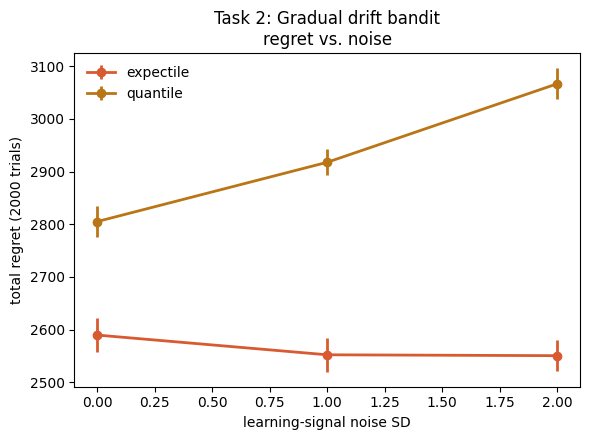

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for rule in ["expectile", "quantile"]:
    sub = df_drift[df_drift.rule == rule].groupby("noise")["total_regret"].agg(["mean", "sem"])
    ax.errorbar(sub.index, sub["mean"], yerr=sub["sem"], marker="o", color=rwu.RULE_COLORS[rule], label=rule, lw=2)
ax.set_xlabel("learning-signal noise SD"); ax.set_ylabel("total regret (2000 trials)")
ax.set_title("Task 2: Gradual drift bandit\nregret vs. noise")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "03_task2_drift.pdf"), bbox_inches="tight")
plt.show()

df_drift.to_csv(os.path.join(ARTIFACT_DIR, "task2_drift.csv"), index=False)

## Task 3: Risk-sensitive survival

In [6]:
RISK_ARMS = [(4.2, 0.0), (5.0, 9.0), (3.8, 0.0), (4.0, 4.0)]  # (mean, var)
ARM_NAMES = ["safe", "optimal (risky)", "below cost", "distracter"]
OPTIMAL_ARM = 1
BUDGET0, COST, N_TRIALS_RISK, N_SEEDS_RISK, ALPHA_RISK, N_TAUS_RISK = 30.0, 4.0, 500, 30, 0.05, 10

def sample_risk_reward(arm, rng):
    mu, var = RISK_ARMS[arm]
    if var < 1e-9:
        return mu
    sd = np.sqrt(var)
    return rng.choice([mu - sd, mu + sd])

def run_risk_bandit(rule, learn_noise_sd=0.0, seed=0):
    rng = np.random.default_rng(seed)
    taus = np.linspace(0.05, 0.95, N_TAUS_RISK)
    V = np.full((len(RISK_ARMS), N_TAUS_RISK), 4.0)
    budget, alive = BUDGET0, True
    choices, budgets = [], []
    survival_trial, time_to_optimal, committed = N_TRIALS_RISK, N_TRIALS_RISK, False
    for t in range(N_TRIALS_RISK):
        if not alive:
            choices.append(-1); budgets.append(0.0)
            continue
        mean_est = V.mean(axis=1)
        pressure = max(0.0, 1.0 - budget / 20.0)
        if pressure > 0.3 and rng.random() > 0.1:
            penalty = pressure * np.maximum(0, COST - V[:, 0])
            arm = int(np.argmax(mean_est - penalty))
        elif rng.random() < 0.1:
            arm = rng.integers(0, len(RISK_ARMS))
        else:
            arm = int(np.argmax(mean_est))
        if not committed and len(choices) >= 10 and all(c == OPTIMAL_ARM for c in choices[-10:]):
            time_to_optimal, committed = t, True
        r_true = sample_risk_reward(arm, rng)
        r_learn = r_true + rng.normal(0, learn_noise_sd) if learn_noise_sd > 0 else r_true
        budget += r_true - COST
        if budget <= 0:
            alive, survival_trial = False, t
        rwu.tau_update(V, taus, arm, r_learn, rule, ALPHA_RISK)
        choices.append(arm); budgets.append(budget)
    return dict(choices=np.array(choices), budgets=np.array(budgets),
                survived=int(survival_trial == N_TRIALS_RISK),
                survival_trial=survival_trial, time_to_optimal=time_to_optimal)

risk_rows = []
for ln_sd in NOISE_LEVELS:
    for rule in ["expectile", "quantile"]:
        for seed in range(N_SEEDS_RISK):
            r = run_risk_bandit(rule, learn_noise_sd=ln_sd, seed=seed)
            valid = r["choices"][r["choices"] >= 0]
            risk_rows.append(dict(rule=rule, noise=ln_sd, seed=seed,
                                   frac_optimal=(valid == OPTIMAL_ARM).mean(),
                                   survived=r["survived"], time_to_optimal=r["time_to_optimal"],
                                   min_budget=r["budgets"].min()))

df_risk = pd.DataFrame(risk_rows)
print("Risk-task results, expectile vs. quantile:")
for ln_sd in NOISE_LEVELS:
    for metric in ["time_to_optimal", "frac_optimal", "survived", "min_budget"]:
        e = df_risk[(df_risk.rule == "expectile") & (df_risk.noise == ln_sd)][metric]
        q = df_risk[(df_risk.rule == "quantile") & (df_risk.noise == ln_sd)][metric]
        if e.std() < 1e-9 and q.std() < 1e-9:
            print(f"  noise={ln_sd:.1f}  {metric:16s}  exp={e.mean():.3f}  quant={q.mean():.3f}  (no variance)")
            continue
        _, p = ttest_ind(e, q)
        print(f"  noise={ln_sd:.1f}  {metric:16s}  exp={e.mean():8.3f}  quant={q.mean():8.3f}  "
              f"diff={e.mean()-q.mean():+8.3f}  p={p:.4f}")

Risk-task results, expectile vs. quantile:
  noise=0.0  time_to_optimal   exp= 273.633  quant= 500.000  diff=-226.367  p=0.0000
  noise=0.0  frac_optimal      exp=   0.448  quant=   0.024  diff=  +0.424  p=0.0000
  noise=0.0  survived          exp=1.000  quant=1.000  (no variance)
  noise=0.0  min_budget        exp=  29.853  quant=  29.853  diff=  +0.000  p=1.0000
  noise=1.0  time_to_optimal   exp= 191.433  quant= 347.200  diff=-155.767  p=0.0039
  noise=1.0  frac_optimal      exp=   0.580  quant=   0.174  diff=  +0.406  p=0.0000
  noise=1.0  survived          exp=1.000  quant=1.000  (no variance)
  noise=1.0  min_budget        exp=  27.693  quant=  25.240  diff=  +2.453  p=0.0387
  noise=2.0  time_to_optimal   exp= 173.733  quant= 201.800  diff= -28.067  p=0.5787
  noise=2.0  frac_optimal      exp=   0.646  quant=   0.530  diff=  +0.116  p=0.2115
  noise=2.0  survived          exp=   1.000  quant=   0.967  diff=  +0.033  p=0.3215
  noise=2.0  min_budget        exp=  25.393  quant=  2

C:\Users\janak\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


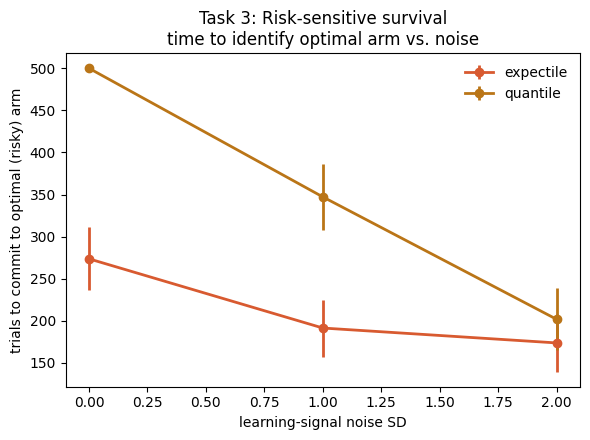

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for rule in ["expectile", "quantile"]:
    sub = df_risk[df_risk.rule == rule].groupby("noise")["time_to_optimal"].agg(["mean", "sem"])
    ax.errorbar(sub.index, sub["mean"], yerr=sub["sem"], marker="o", color=rwu.RULE_COLORS[rule], label=rule, lw=2)
ax.set_xlabel("learning-signal noise SD"); ax.set_ylabel("trials to commit to optimal (risky) arm")
ax.set_title("Task 3: Risk-sensitive survival\ntime to identify optimal arm vs. noise")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "03_task3_risk.pdf"), bbox_inches="tight")
plt.show()

df_risk.to_csv(os.path.join(ARTIFACT_DIR, "task3_risk.csv"), index=False)